In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/semanurcan/Desktop/veri/birlesik_veri.csv")
df.head()

,hour,passenger_count,vehicle_type,route_code,stop_code,district,is_outlier,is_peak_hour,mean_passenger_by_route_hour
0,0,2,2,KIRAZLI-BASAKSEHIR/METROKENT,RAYLI,BAGCILAR,0,0,1.532982
1,0,2,2,YENIKAPI - HAVALIMANI,RAYLI,BAHCELIEVLER,0,0,2.980226
2,0,1,2,BAHARIYE-OLIMPIYAT,RAYLI,BAKIRKOY,0,0,1.473945
3,0,9,2,KABATAS-BAGCILAR,RAYLI,BAKIRKOY,1,0,3.376855
4,0,2,2,YENIKAPI - HACIOSMAN,RAYLI,BEYOGLU,0,0,2.826446


Çalışmada kullanılacak veri seti birlesik_veri.csv dosyasından okunmuştur.

In [2]:
def create_density_class(x):
    if x < 20:
        return 0   
    elif x < 50:
        return 1   
    else:
        return 2   

df["density_class"] = df["passenger_count"].apply(create_density_class)
df["density_class"].value_counts()

density_class
0    4294024
1     197491
2     107755
Name: count, dtype: int64

Yolcu yoğunluğunu temsil eden **density_class** değişkeni, **passenger_count** değişkeni kullanılarak oluşturulmuştur.
Yolcu sayısına göre üç farklı yoğunluk seviyesi tanımlanmıştır:

- 0: Düşük yoğunluk

- 1: Orta yoğunluk

- 2: Yüksek yoğunluk

Bu sınıflandırma ile sürekli bir değişken olan yolcu sayısı, sınıflandırma modellerinde kullanılabilecek kategorik bir hedef değişkene dönüştürülmüştür.
Oluşturulan sınıfların dağılımı **value_counts()** fonksiyonu ile incelenmiştir.

In [3]:
feature_cols = [
    "hour",
    "vehicle_type",
    "district",
    "route_code",
    "stop_code",
    "is_outlier",
    "is_peak_hour",
    "mean_passenger_by_route_hour"
]

X = df[feature_cols]
y = df["density_class"]

Model eğitiminde kullanılacak bağımsız değişkenler *feature_cols* listesi içerisinde tanımlanmıştır.
Hedef değişken olarak, yolcu yoğunluğunu temsil eden *density_class* seçilmiştir.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- Veri seti, modelin eğitimi ve performans değerlendirmesi için eğitim ve test kümelerine ayrılmıştır.

- Verinin **%80’i eğitim**, **%20’si test** amacıyla kullanılmıştır.

- **stratify=y** parametresi ile her yoğunluk sınıfının eğitim ve test setlerinde aynı oranda bulunması sağlanmıştır.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_cols = ["vehicle_type", "district", "route_code", "stop_code"]
numeric_cols = [
    "hour",
    "is_outlier",
    "is_peak_hour",
    "mean_passenger_by_route_hour"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

- Kategorik değişkenler **One-Hot Encoding** yöntemi ile sayısal forma dönüştürülmüştür.
- Sayısal değişkenler **hour, is_outlier, is_peak_hour, mean_passenger_by_route_hour** doğrudan modele aktarılmıştır.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

- RandomForestClassifier modeli, tekrarlanabilir sonuçlar elde etmek amacıyla *random_state=42* ile tanımlanmıştır.
- Veri ön işleme ile model tek bir akışta birleştirilmiştir.

In [7]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=4,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_train, y_train)

print("Best Params:", rf_search.best_params_)
print("Best CV f1_macro:", rf_search.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END model__class_weight=balanced, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time= 2.9min
[CV] END model__class_weight=balanced, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time= 2.8min
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=150; total time=  42.8s
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=150; total time=  44.5s
[CV] END model__class_weight=balanced, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=150; total time=  50.0s
[CV] END model__

- Random Forest modeli için hiperparametre araması yapılmıştır.
- **param_dist** ile modelin öğrenme kapasitesini etkileyen temel parametreler tanımlanmıştır.
- **StratifiedKFold** kullanılarak her katmanda sınıf dağılımının korunması sağlanmıştır.
- **RandomizedSearchCV**, tüm kombinasyonları denemek yerine rastgele örnekleme yaparak hesaplama maliyetini düşürmüştü.
- Değerlendirme metriği olarak sınıf dengesizliğine duyarlı olan **f1_macro** tercih edilmiştir.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    858805
           1       0.34      0.57      0.42     39498
           2       0.31      0.80      0.44     21551

    accuracy                           0.91    919854
   macro avg       0.55      0.77      0.61    919854
weighted avg       0.96      0.91      0.93    919854

[[796423  40028  22354]
 [    75  22409  17014]
 [    11   4193  17347]]


- Test verisi üzerinde tahminler **(y_pred)** üretilmiştir.
- classification_report ile her sınıf için **precision**, **recall** ve **F1-score** hesaplanmıştır.
- **confusion_matrix** kullanılarak sınıflar arası karışmalar analiz edilmiştir.

In [9]:
print("unique y_test:", np.unique(y_test))
print("n_classes:", len(np.unique(y_test)))

unique y_test: [0 1 2]
n_classes: 3


**np.unique(y_test)** ile test kümesinde bulunan sınıf etiketleri kontrol edilmişti

In [10]:
import pandas as pd
from sklearn.metrics import classification_report

class_names = ["Deniz", "Kara", "Raylı"]

report = classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).T

class_metrics = df_report.loc[
    class_names,
    ["precision", "recall", "f1-score", "support"]
]

class_metrics

,precision,recall,f1-score,support
Deniz,0.999892,0.927362,0.962262,858805.0
Kara,0.336320,0.567345,0.422301,39498.0
Raylı,0.305863,0.804928,0.443283,21551.0


- Random Forest modeli tarafından üretilen tahminler kullanılarak **Deniz, Kara** ve **Raylı** sınıfları için ayrı ayrı
precision, recall, f1-score ve support metrikleri hesaplanmıştır.

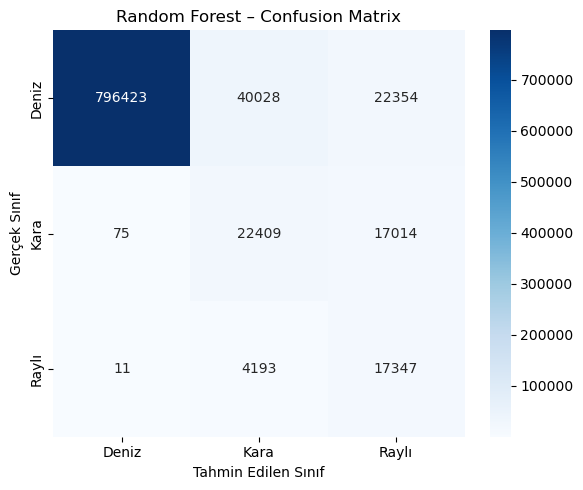

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["Deniz", "Kara", "Raylı"]

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Random Forest – Confusion Matrix")
plt.tight_layout()
plt.show()

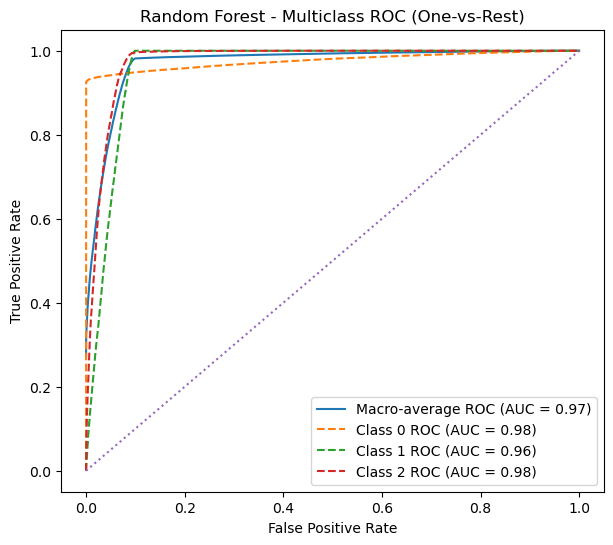

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

y_proba = best_rf.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

all_fpr = np.unique(np.concatenate([fpr[c] for c in classes]))
mean_tpr = np.zeros_like(all_fpr)

for c in classes:
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.2f})")

for c in classes:
    plt.plot(fpr[c], tpr[c], linestyle="--", label=f"Class {c} ROC (AUC = {roc_auc[c]:.2f})")

plt.plot([0,1], [0,1], linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - Multiclass ROC (One-vs-Rest)")
plt.legend()
plt.show()
